# Libraries & Set up

In [1]:
%run ../../../setup_workspace.py

✓ Workspace ready


# Data

In [3]:
path = r"D:\НИР\2025-2026\PLA\Synology\SC5671-ID13\RAW_DATA\COPO-500-STR75C-2\sc5671_COPO-500-STR75C-2.h5"
file = h5py.File(path, 'r')
data = file['COPO-500-STR75C-2_fiber_run1_1.1']['measurement']['eiger']
img = data[99]

poni = r"D:\НИР\2025-2026\PLA\Synology\SC5671-ID13\PROCESSED_DATA\al2o3_a1.poni"
ai = pyFAI.load(poni)

mask = r"D:\НИР\2025-2026\PLA\Synology\SC5671-ID13\PROCESSED_DATA\mask1.edf"
img_mask = fabio.open(mask).data

# ...
# ...
# ...

[]

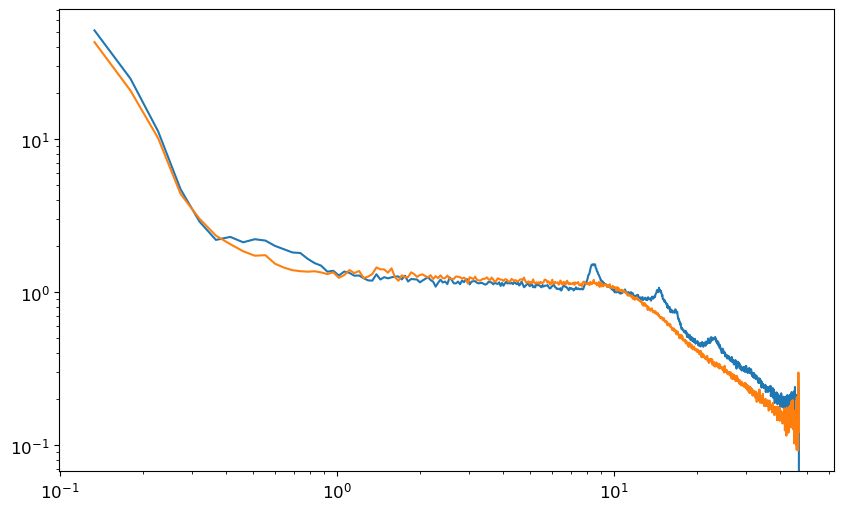

In [4]:
img = data[10]
q, I = ai.integrate1d(img, 1000, mask=img_mask, unit='q_nm^-1')
plt.plot(q,I)

img = data[150]
q, I = ai.integrate1d(img, 1000, mask=img_mask, unit='q_nm^-1')
plt.plot(q,I)

plt.semilogx()
plt.semilogy()

# Function

In [11]:
def integrate1d(path_edf, ai, npt, mask=None, unit='q_nm^-1'):
    
    img = fabio.open(path_edf).data
    res_1D = ai.integrate1d(img, npt, mask=mask, unit=unit)
        
    return res_1D[0], res_1D[1]

# Analysis

(0.1, 3)

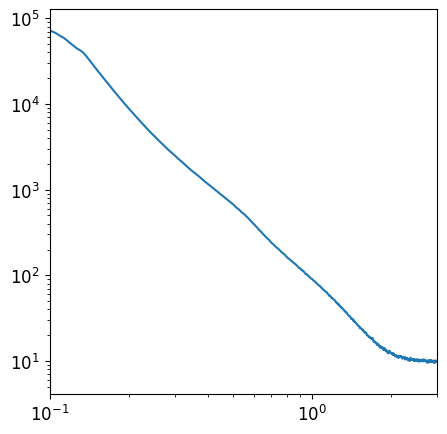

In [16]:
q, I = Some_Experiment.get_1d_SAXS()


plt.figure(figsize=(5,5))
plt.plot(q, I)

p, cov = curve_fit(linear, q, I)

plt.semilogx()
plt.semilogy()
plt.xlim(0.1, 3)
